In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")
print("Library siap!")

Library siap!


In [2]:
df = pd.read_csv("world_happiness_report_2005_2025.csv")  # sesuaikan nama file
print(f"Shape: {df.shape}")
df.head()

Shape: (2116, 13)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("=== Info Dataset ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTahun tersedia: {sorted(df['year'].unique())}")
print(f"Jumlah negara unik: {df['country'].nunique()}")

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               

In [4]:
print("=== Info Dataset ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTahun tersedia: {sorted(df['year'].unique())}")
print(f"Jumlah negara unik: {df['country'].nunique()}")

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               

In [5]:
df.describe().T.style.background_gradient(cmap='YlOrRd', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
year,2116.000000,2018.220227,4.249844,2011.000000,2015.000000,2018.000000,2022.000000,2025.000000
rank_in_year,2116.000000,76.190926,43.845101,1.000000,38.000000,76.000000,114.000000,158.000000
happiness_score,2116.000000,5.465655,1.123870,1.364000,4.604750,5.480000,6.321250,7.856000
lower_whisker,1022.000000,5.436091,1.140959,1.301000,4.619707,5.592631,6.290110,7.780000
upper_whisker,1022.000000,5.664733,1.107424,1.427000,4.867750,5.812000,6.486500,7.904000
explained_log_gdp_per_capita,1019.000000,1.265670,0.463823,0.000000,0.944000,1.304000,1.636000,2.209000
explained_social_support,1019.000000,1.096746,0.357642,0.000000,0.865000,1.140119,1.382000,1.840000
explained_healthy_life_expectancy,1016.000000,0.553435,0.229980,0.000000,0.389750,0.560500,0.712325,1.238000
explained_freedom,1017.000000,0.609465,0.212070,0.000000,0.471000,0.602000,0.735000,1.147000
explained_generosity,1019.000000,0.147343,0.084335,0.000000,0.088000,0.134000,0.195477,0.569814


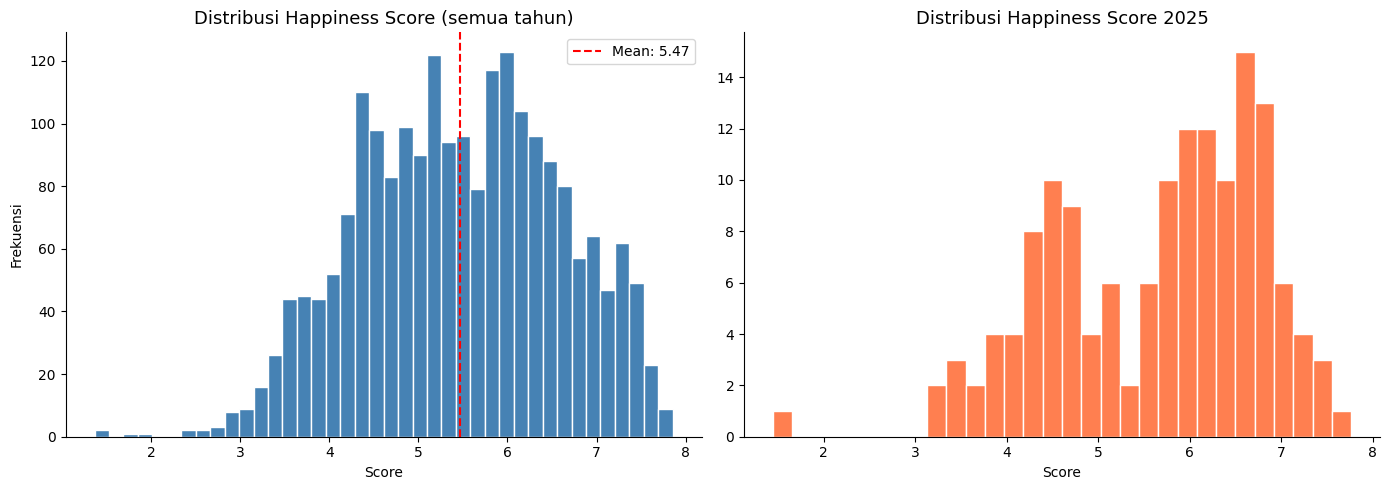

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['happiness_score'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Happiness Score (semua tahun)', fontsize=13)
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['happiness_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['happiness_score'].mean():.2f}")
axes[0].legend()

# Per tahun terakhir
latest = df[df['year'] == df['year'].max()]
axes[1].hist(latest['happiness_score'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1].set_title(f"Distribusi Happiness Score {df['year'].max()}", fontsize=13)
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

dari hasil grafik yang diperoleh bisa dilihat bahwa bentuk grafik mendekati normal dengan rata-rata garis 5.47 dan mayoritas di sekitar rentang 4.5-6.5. Pada grafik Distribusi Happines Score 2025 dimana banyak negara yang memiliki skor yang tinggi meskipun masih ada beberapa negara yang skor rendah.

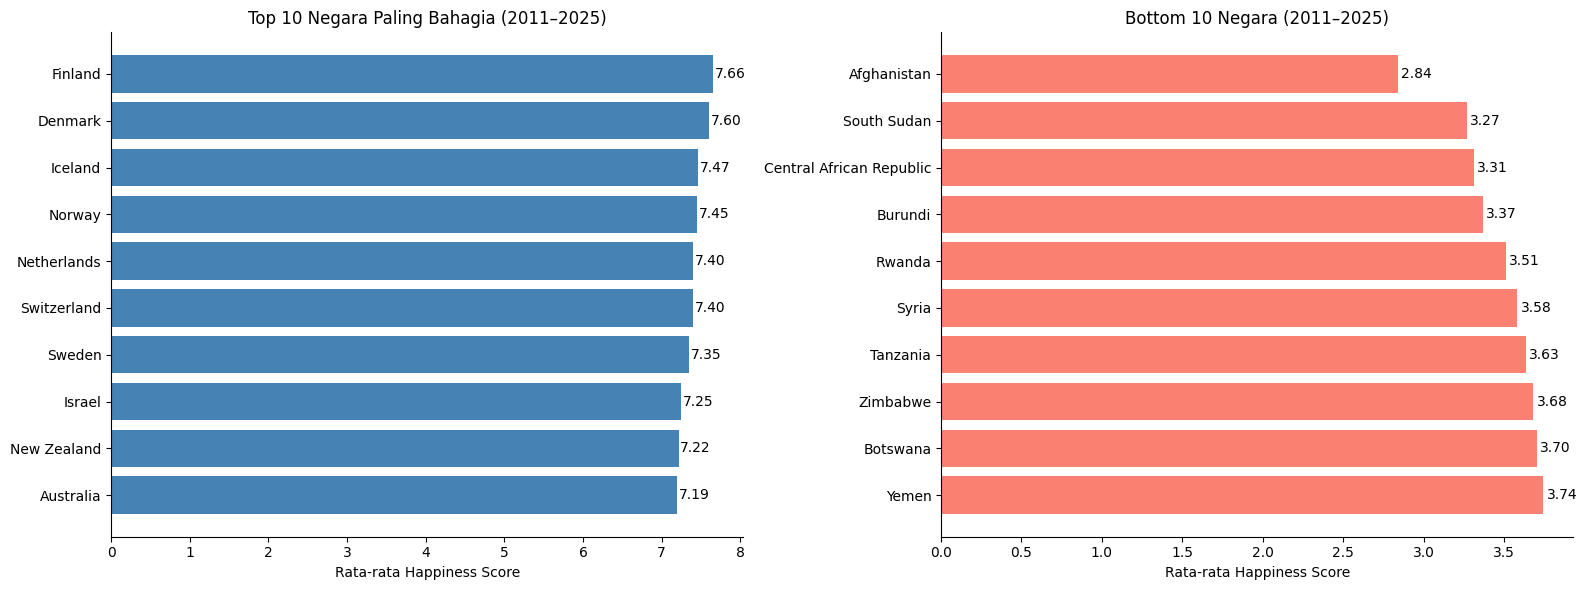

In [7]:
avg_score = df.groupby('country')['happiness_score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
top10 = avg_score.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Negara Paling Bahagia (2011–2025)', fontsize=12)
axes[0].set_xlabel('Rata-rata Happiness Score')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v + 0.02, i, f"{v:.2f}", va='center', fontsize=10)

# Bottom 10
bot10 = avg_score.tail(10)
axes[1].barh(bot10.index, bot10.values, color='salmon')
axes[1].set_title('Bottom 10 Negara (2011–2025)', fontsize=12)
axes[1].set_xlabel('Rata-rata Happiness Score')
for i, v in enumerate(bot10.values):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

Dari grafik bisa dilihat bahwa Finland menjadi negara paling bahagia karena berada di posisi pertama dan Afganistan menjadi negara paling bahagia terendah.

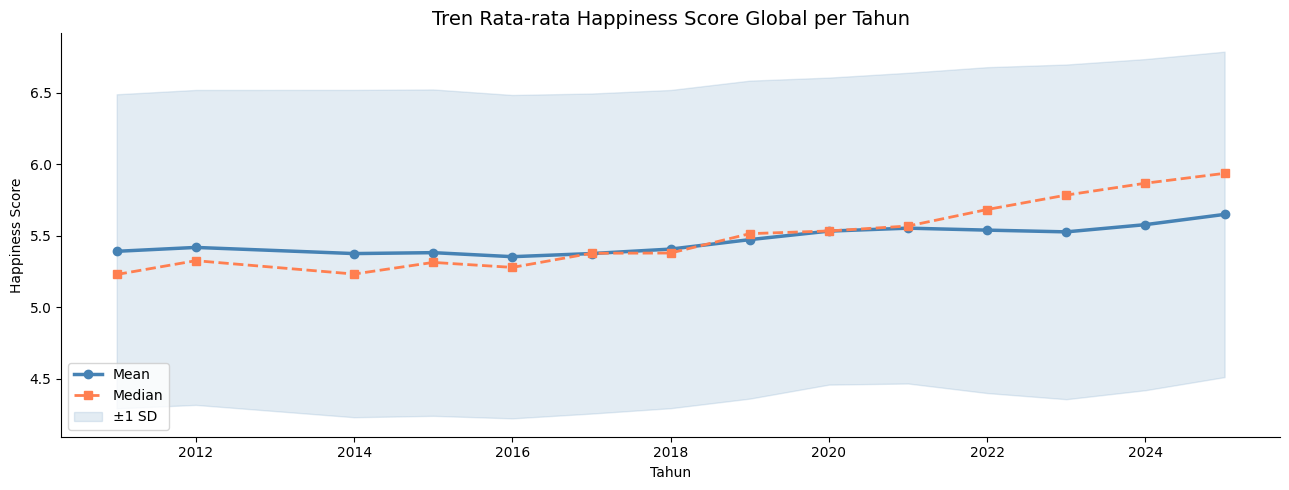

In [8]:
yearly = df.groupby('year')['happiness_score'].agg(['mean','median','std']).reset_index()

plt.figure(figsize=(13, 5))
plt.plot(yearly['year'], yearly['mean'], 'o-', label='Mean', linewidth=2.5, color='steelblue')
plt.plot(yearly['year'], yearly['median'], 's--', label='Median', linewidth=2, color='coral')
plt.fill_between(yearly['year'],
                 yearly['mean'] - yearly['std'],
                 yearly['mean'] + yearly['std'],
                 alpha=0.15, color='steelblue', label='±1 SD')
plt.title('Tren Rata-rata Happiness Score Global per Tahun', fontsize=14)
plt.xlabel('Tahun'); plt.ylabel('Happiness Score')
plt.legend(); plt.tight_layout()
plt.show()

Dari struktur bisa dilihat bahwa setiap tahun terjadi peningkatan di tren mean meskipun sedikit fluktuatif di sekitar 2016-2018 dan pada tren median bisa dilihat lebih konsisten dibandingkan dengan mean dan bahkan melampui mean sehingga Median naik lebih cepat → perbaikan lebih merata di banyak negara

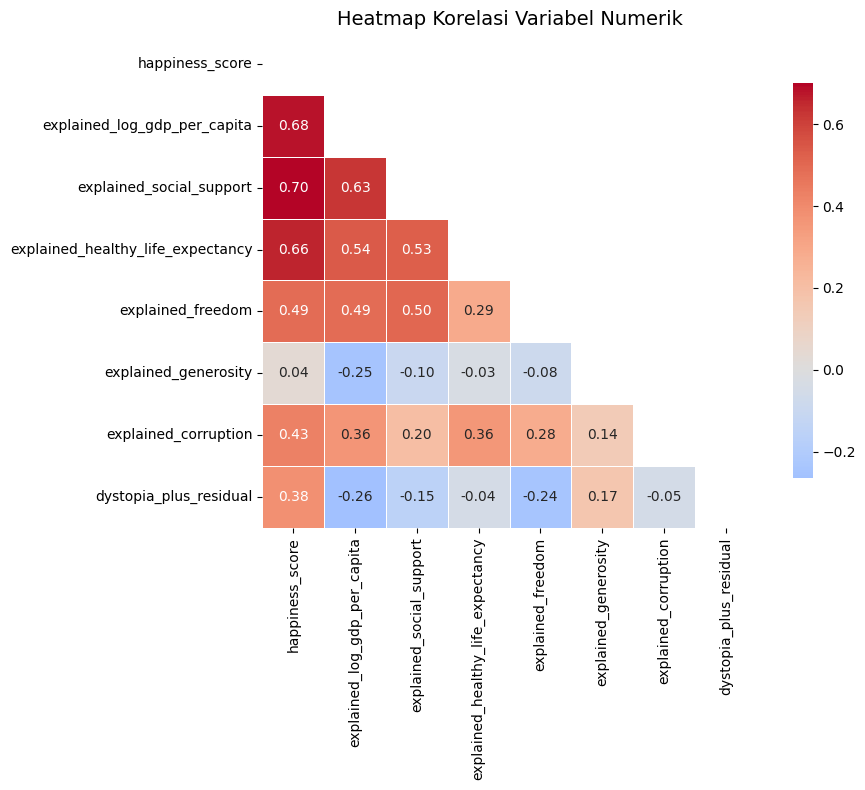

In [9]:
num_cols = ['happiness_score', 'explained_log_gdp_per_capita', 'explained_social_support',
            'explained_healthy_life_expectancy', 'explained_freedom',
            'explained_generosity', 'explained_corruption', 'dystopia_plus_residual']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14)
plt.tight_layout()
plt.show()

Pada heatmap tersebut bisa diperhatikan bahwa terdapat hubungan antar faktor bisa dilihat hubungannya seperti berikut
social support (0.70) dimana menjadi faktor terkuat yang memiliki hubungan dengan kebahagiaan(happiness_score) bisa dilihat semakin tinggi dukungan social maka semakin bahagia. Dengan tingginya GDP per capita akan cenderung bahagia. Serta kesehatan berperan besar dalam meningkatkan kebahagiaan.

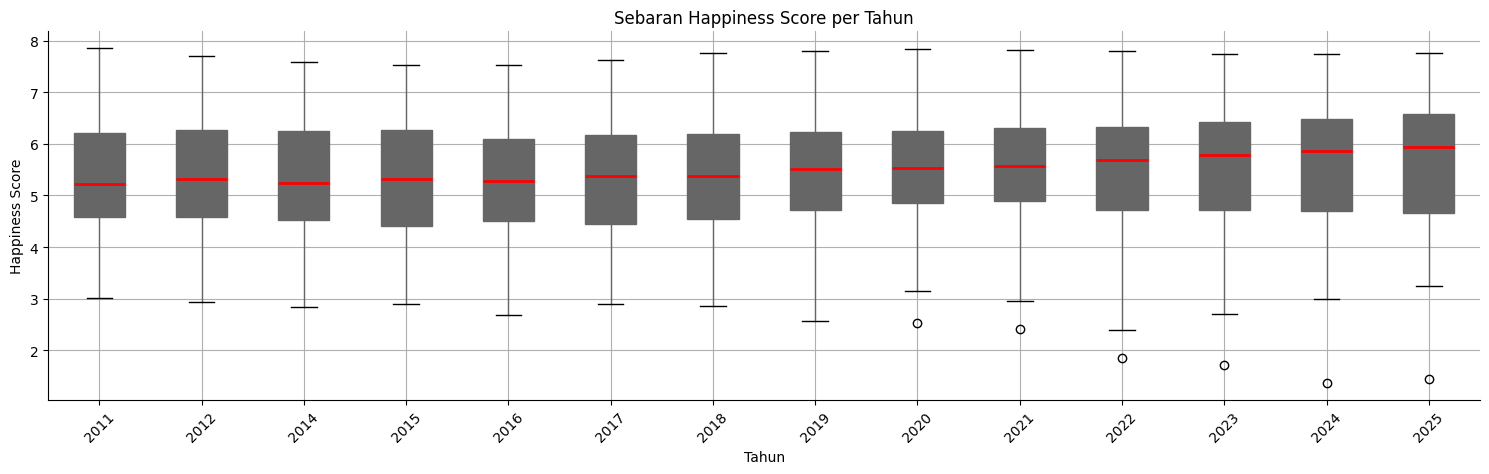

In [10]:
plt.figure(figsize=(15, 5))
df.boxplot(column='happiness_score', by='year', ax=plt.gca(),
           patch_artist=True, medianprops={'color': 'red', 'linewidth': 2})
plt.title('Sebaran Happiness Score per Tahun')
plt.suptitle('')
plt.xlabel('Tahun'); plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

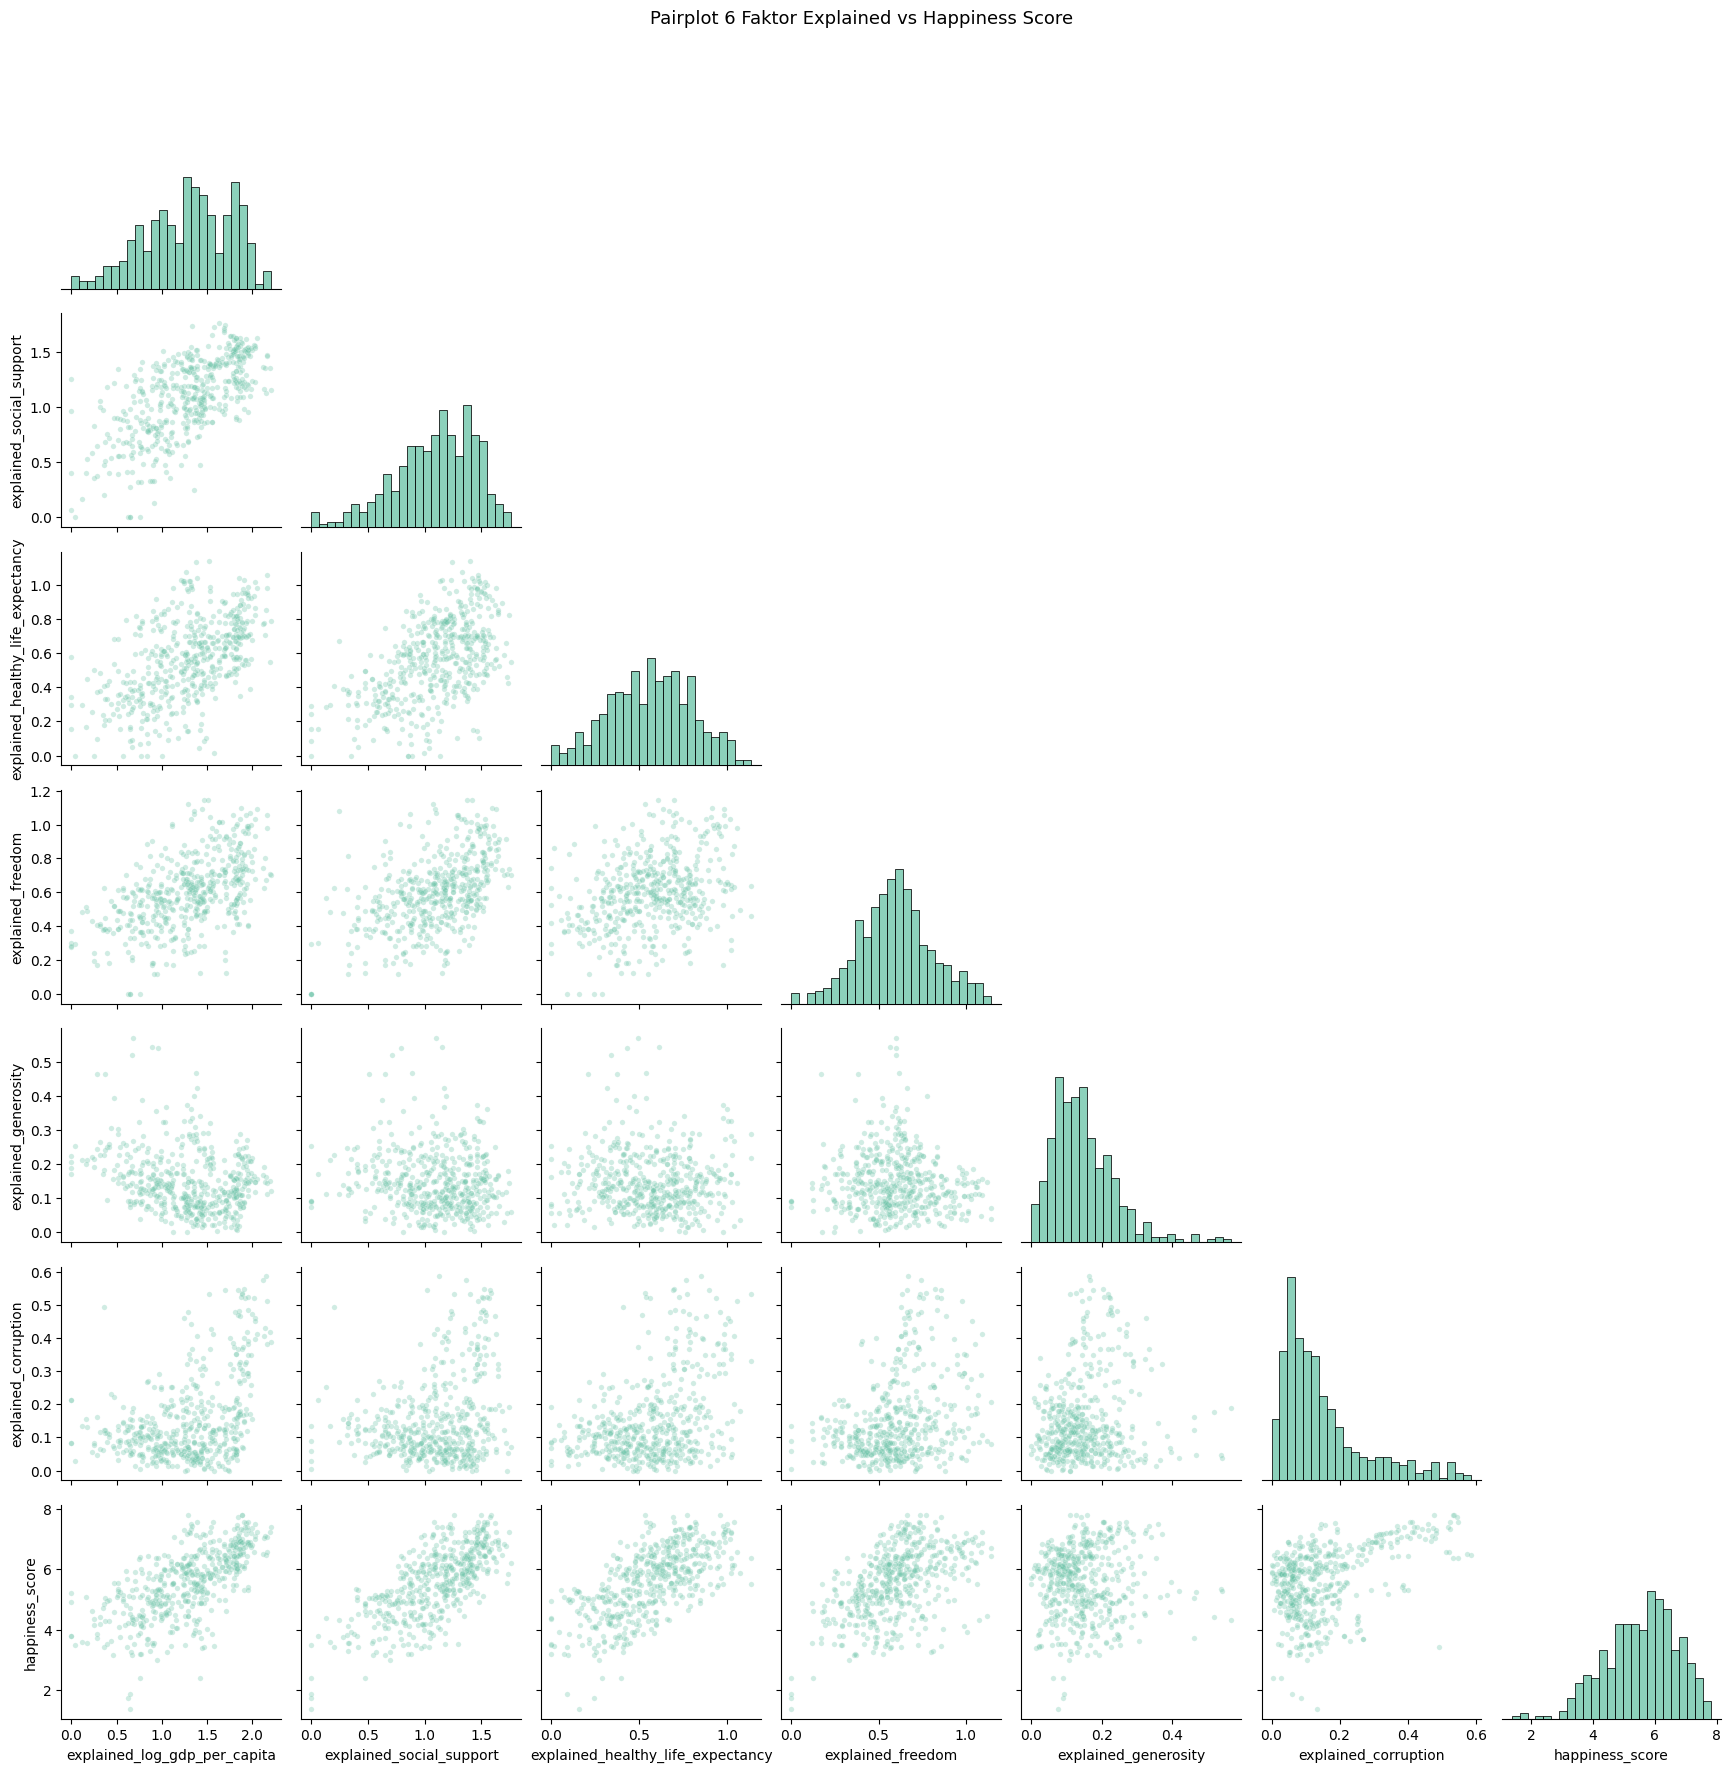

In [11]:
explained_cols = ['explained_log_gdp_per_capita', 'explained_social_support',
                  'explained_healthy_life_expectancy', 'explained_freedom',
                  'explained_generosity', 'explained_corruption']

sample = df[explained_cols + ['happiness_score']].dropna().sample(500, random_state=42)
sns.pairplot(sample, plot_kws={'alpha': 0.3, 's': 15},
             diag_kws={'bins': 25}, corner=True)
plt.suptitle('Pairplot 6 Faktor Explained vs Happiness Score', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

dari hasil kluster tersebut bisa kita dapatkan informasi mengenai
GDP per kapita (explained_log_gdp_per_capita), semakin tinggi pendapatan
semakin tinggi kebahagiaan. Hal ini bisa dilihat melalui pola titik membentuk garis naik yang cukup jelas.

Social support (explained_social_support), Dukungan sosial kuat → kebahagiaan meningkat dengan melihat hubungan tersebut jelas.

Healthy life expectancy (explained_healthy_life_expectancy), harapan hidup sehat tinggi akan menjadi lebih bahagia dan bisa dilihat korelasinya cukup kuat.

Terdapat juga hubungan yang tidak terlalu tinggi seperti explained_freedom, explained_generosity dan explained_corruption)



In [12]:
region_map = {
    'Finland':'Europe','Denmark':'Europe','Sweden':'Europe','Norway':'Europe',
    'Netherlands':'Europe','Switzerland':'Europe','Germany':'Europe','Austria':'Europe',
    'Iceland':'Europe','Luxembourg':'Europe','Ireland':'Europe','Belgium':'Europe',
    'France':'Europe','Spain':'Europe','Italy':'Europe','Portugal':'Europe',
    'United Kingdom':'Europe','Czech Republic':'Europe','Poland':'Europe',
    'Hungary':'Europe','Romania':'Europe','Bulgaria':'Europe','Greece':'Europe',
    'Serbia':'Europe','Croatia':'Europe','Slovakia':'Europe','Slovenia':'Europe',
    'United States':'North America','Canada':'North America','Mexico':'Latin America',
    'Brazil':'Latin America','Argentina':'Latin America','Chile':'Latin America',
    'Colombia':'Latin America','Peru':'Latin America','Venezuela':'Latin America',
    'Costa Rica':'Latin America','Uruguay':'Latin America','Panama':'Latin America',
    'China':'Asia','Japan':'Asia','South Korea':'Asia','India':'Asia',
    'Indonesia':'Asia','Thailand':'Asia','Vietnam':'Asia','Philippines':'Asia',
    'Malaysia':'Asia','Singapore':'Asia','Taiwan Province of China':'Asia',
    'Australia':'Oceania','New Zealand':'Oceania',
    'South Africa':'Sub-Saharan Africa','Nigeria':'Sub-Saharan Africa',
    'Kenya':'Sub-Saharan Africa','Ghana':'Sub-Saharan Africa','Ethiopia':'Sub-Saharan Africa',
    'Israel':'Middle East & North Africa','Saudi Arabia':'Middle East & North Africa',
    'UAE':'Middle East & North Africa','Iran':'Middle East & North Africa',
    'Egypt':'Middle East & North Africa','Morocco':'Middle East & North Africa',
    'Turkey':'Middle East & North Africa',
}

df['region'] = df['country'].map(region_map).fillna('Other')
print(df['region'].value_counts())

region
Other                         1290
Europe                         364
Latin America                  140
Asia                           126
Middle East & North Africa      70
Sub-Saharan Africa              70
Oceania                         28
North America                   28
Name: count, dtype: int64


In [13]:
df_sorted = df.sort_values(['country', 'year'])
df_sorted['score_yoy'] = df_sorted.groupby('country')['happiness_score'].diff()

# Negara dengan perubahan terbesar (2025 vs pertama kali muncul)
first_last = df_sorted.groupby('country').agg(
    score_first=('happiness_score', 'first'),
    score_last=('happiness_score', 'last'),
    year_first=('year', 'first'),
    year_last=('year', 'last')
).dropna()

first_last['total_change'] = first_last['score_last'] - first_last['score_first']
print("=== Kenaikan Terbesar ===")
print(first_last.nlargest(10, 'total_change')[['score_first','score_last','total_change']])
print("\n=== Penurunan Terbesar ===")
print(first_last.nsmallest(10, 'total_change')[['score_first','score_last','total_change']])

=== Kenaikan Terbesar ===
                        score_first  score_last  total_change
country                                                      
Serbia                        4.564       6.691         2.127
Bulgaria                      3.889       5.703         1.814
Georgia                       3.892       5.517         1.625
Latvia                        4.762       6.365         1.603
Bosnia and Herzegovina        4.857       6.381         1.524
Kosovo                        5.420       6.910         1.490
Romania                       5.178       6.629         1.451
China                         4.680       6.074         1.394
Philippines                   4.825       6.206         1.381
Mongolia                      4.562       5.936         1.374

=== Penurunan Terbesar ===
              score_first  score_last  total_change
country                                            
Afghanistan         4.258      1.4460       -2.8120
Malawi              4.624      3.2840       -1

Pada hasil tersebut bisa dilihat terjadi kenaikan dan penurunan pada beberapa negara. Pada tabel pertama yaitu kenaikan kebahagiaan terbesar ada di Serbia, diikuti Bulgaria. Kenaikan ini terjadi karena kualitas hidup di negara tersebut membaik cukup drastis. Biasanya disebabkan oleh faktor seperti ekonomi membaik, stabilitas politik meningkat, dan sistem sosial lebih kuat.

Sedangkan penurunan terbesar berada pada negara Afghanistan yang sangat ekstrem diikuti oleh Malawi dan Lebanon. Ini biasanya terjadi karena negara tersebut sering kali konflik/perang dan bisa juga disebabkan oleh krisis ekonomi.

Dari kedua tabel bisa kita lihat perbandingan bahwa negara yang mengalami kenaikan happiness score banyak dari negara Eropa Timur dan Asia dan yang turun kebanyakan dari wilayah konflik (Timur Tengah) dan negara dengan krisis ekonomi.

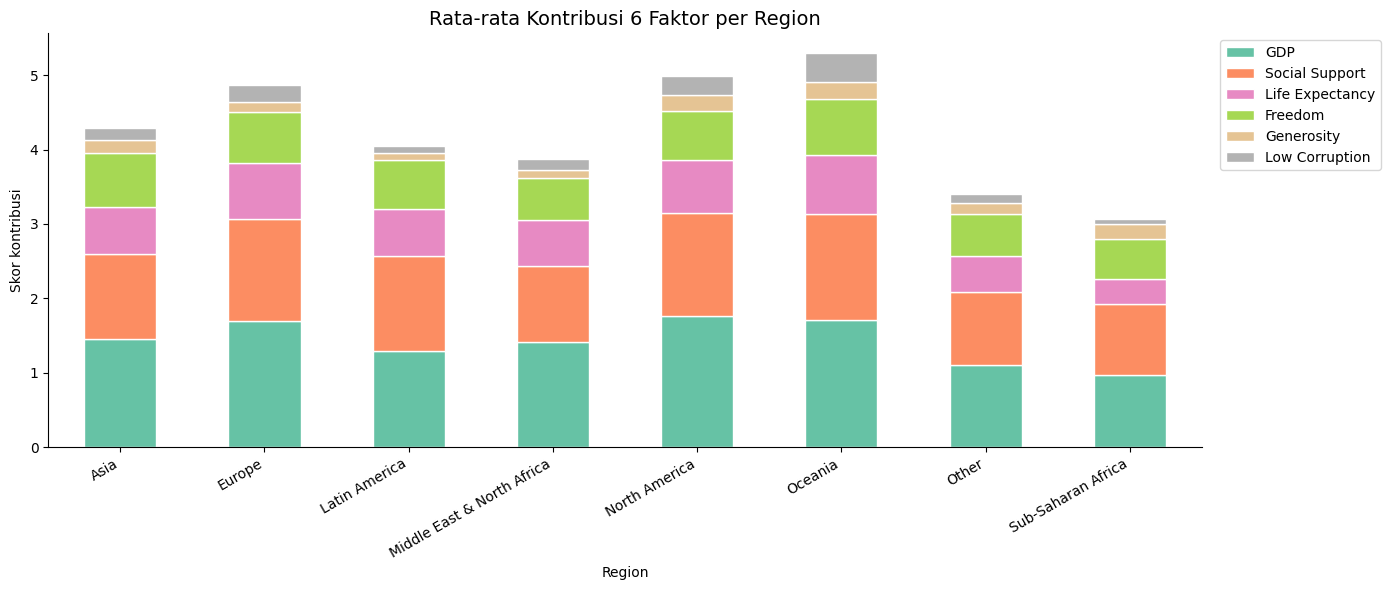

In [14]:
factor_cols = ['explained_log_gdp_per_capita', 'explained_social_support',
               'explained_healthy_life_expectancy', 'explained_freedom',
               'explained_generosity', 'explained_corruption']

labels = ['GDP', 'Social Support', 'Life Expectancy', 'Freedom', 'Generosity', 'Low Corruption']

region_factors = df.groupby('region')[factor_cols].mean()
region_factors.columns = labels

region_factors.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2', edgecolor='white')
plt.title('Rata-rata Kontribusi 6 Faktor per Region', fontsize=14)
plt.xlabel('Region'); plt.ylabel('Skor kontribusi')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

pada diagram tersebut bisa dilihat bahwa faktor ekonomi menjadi kontribusi utama dalam skor kebahagian suatu negara diikuti dengan Social Support. Jadi dapat disimpulkan bahwa kebahagiaan antar region terutama disebabkan oleh :
1. Kesenjangan ekonomi
2. Perbedaan kualitas dukungan sosial
3. Kesehatan dan harapan hidup

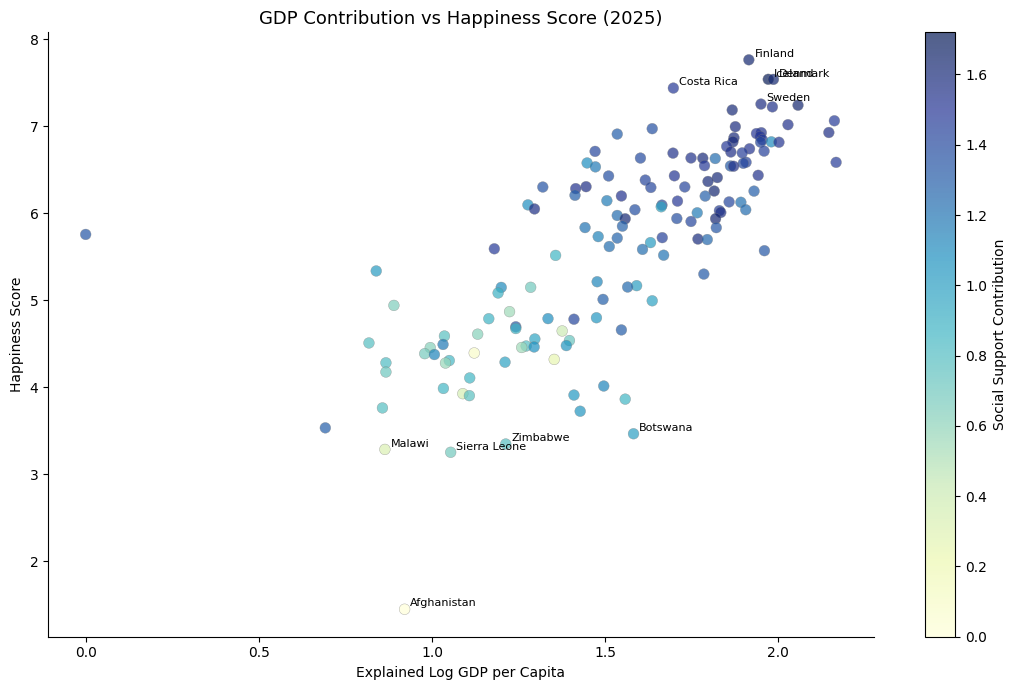

In [15]:
latest_year = df['year'].max()
latest = df[df['year'] == latest_year].dropna(subset=['explained_log_gdp_per_capita', 'happiness_score'])

plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    latest['explained_log_gdp_per_capita'],
    latest['happiness_score'],
    c=latest['explained_social_support'],
    cmap='YlGnBu', s=60, alpha=0.7, edgecolor='gray', linewidth=0.3
)
plt.colorbar(scatter, label='Social Support Contribution')

# Label beberapa negara
for _, row in latest.nlargest(5, 'happiness_score').iterrows():
    plt.annotate(row['country'], (row['explained_log_gdp_per_capita'], row['happiness_score']),
                 fontsize=8, xytext=(4, 2), textcoords='offset points')
for _, row in latest.nsmallest(5, 'happiness_score').iterrows():
    plt.annotate(row['country'], (row['explained_log_gdp_per_capita'], row['happiness_score']),
                 fontsize=8, xytext=(4, 2), textcoords='offset points')

plt.title(f'GDP Contribution vs Happiness Score ({latest_year})', fontsize=13)
plt.xlabel('Explained Log GDP per Capita'); plt.ylabel('Happiness Score')
plt.tight_layout(); plt.show()

Berdasarkan grafik tersebut terlihat bahwa korelatif antara GDP dengan Happines Score dimana semakin tinggi GDP per kapita, semakin tinggi happines score. Tidak hanya itu peran Social Support juga terlihat pada grafik tersebut bahwa Negara dengan warna lebih gelap (dukungan sosial tinggi) cenderung berada di bagian atas (lebih bahagia). Artinya, GDP saja tidak cukup karena social support memperkuat kebahagiaan. Dari grafik bisa dilihat bahwa negara dengan skor tinggi seperti Finland, Denmark, Iceland, Sweden memiliki GDP tinggi, Social Support tinggi.

In [16]:
df_sorted = df.sort_values(['country', 'year']).copy().reset_index(drop=True)

# Lag features
df_sorted['score_lag1'] = df_sorted.groupby('country')['happiness_score'].shift(1)
df_sorted['score_lag2'] = df_sorted.groupby('country')['happiness_score'].shift(2)
df_sorted['score_lag3'] = df_sorted.groupby('country')['happiness_score'].shift(3)
df_sorted['rank_lag1']  = df_sorted.groupby('country')['rank_in_year'].shift(1)
df_sorted['score_yoy_change'] = df_sorted['score_lag1'] - df_sorted['score_lag2']

df_sorted['score_rolling_mean3'] = (
    df_sorted.groupby('country')['happiness_score']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

FEATURES_VALID = ['score_lag1', 'score_lag2', 'score_lag3',
                  'score_rolling_mean3', 'score_yoy_change',
                  'rank_lag1', 'year']
TARGET = 'happiness_score'

# 'year' sudah ada di FEATURES_VALID, jangan tambahkan lagi di sini
cols_needed = list(dict.fromkeys(FEATURES_VALID + [TARGET, 'country']))  # deduplikasi
df_ml = df_sorted[cols_needed].dropna().reset_index(drop=True)

# Verifikasi tidak ada kolom duplikat
assert df_ml.columns.is_unique, f"Kolom duplikat: {df_ml.columns[df_ml.columns.duplicated()].tolist()}"

SPLIT_YEAR = 2022
train = df_ml[df_ml['year'] <= SPLIT_YEAR].reset_index(drop=True)
test  = df_ml[df_ml['year'] >  SPLIT_YEAR].reset_index(drop=True)

X_train = train[FEATURES_VALID]
y_train = train[TARGET]
X_test  = test[FEATURES_VALID]
y_test  = test[TARGET]

print(f"Train: {X_train.shape} (s/d {SPLIT_YEAR})")
print(f"Test:  {X_test.shape}  ({SPLIT_YEAR+1}–{df_ml['year'].max()})")

Train: (1184, 7) (s/d 2022)
Test:  (434, 7)  (2023–2025)


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer

# FEATURES = ['explained_log_gdp_per_capita', 'explained_social_support',
#             'explained_healthy_life_expectancy', 'explained_freedom',
#             'explained_generosity', 'explained_corruption', 'dystopia_plus_residual']
# TARGET = 'happiness_score'

# df_ml = df[FEATURES + [TARGET]].dropna()
# X = df_ml[FEATURES]
# y = df_ml[TARGET]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train)
# X_test_sc = scaler.transform(X_test)

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (810, 7), Test: (203, 7)


In [17]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Scaling — fit hanya pada train, transform keduanya
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    X_fit  = X_train_sc if 'Regression' in name else X_train
    X_pred = X_test_sc  if 'Regression' in name else X_test
    model.fit(X_fit, y_train)
    y_pred = model.predict(X_pred)
    results[name] = {
        'RMSE':   np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':    mean_absolute_error(y_test, y_pred),
        'R²':     r2_score(y_test, y_pred),
        'model':  model,
        'y_pred': y_pred
    }
    print(f"{name:25s} | RMSE: {results[name]['RMSE']:.4f} | MAE: {results[name]['MAE']:.4f} | R²: {results[name]['R²']:.4f}")

Linear Regression         | RMSE: 0.1804 | MAE: 0.1291 | R²: 0.9753
Ridge Regression          | RMSE: 0.1802 | MAE: 0.1289 | R²: 0.9754
Random Forest             | RMSE: 0.2072 | MAE: 0.1473 | R²: 0.9675
Gradient Boosting         | RMSE: 0.2254 | MAE: 0.1527 | R²: 0.9615


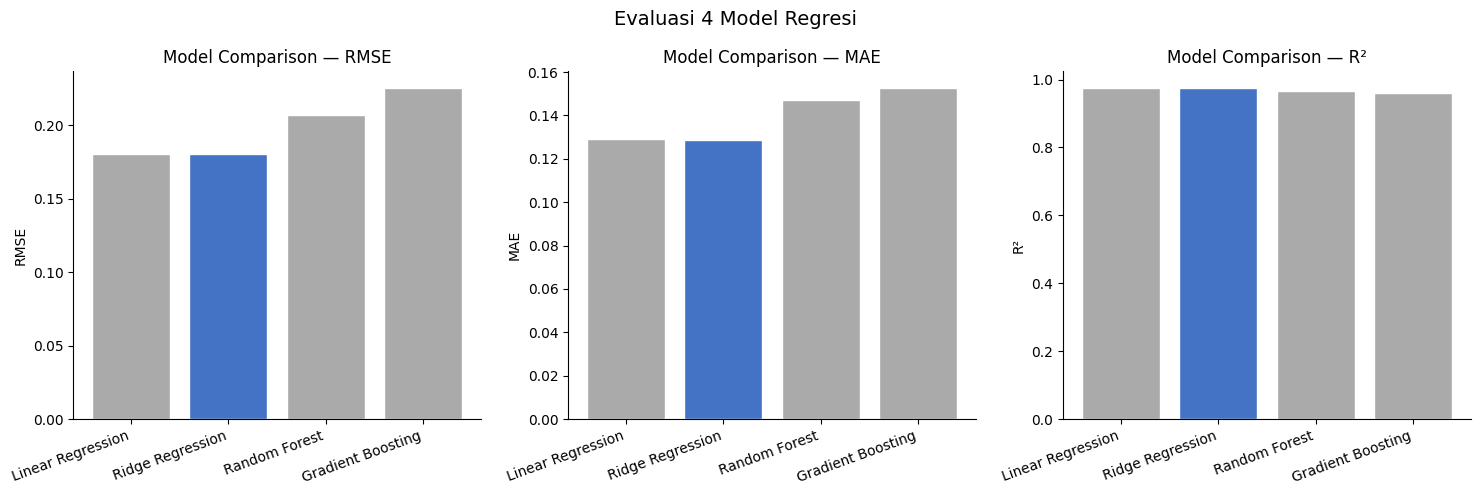

In [18]:
metrics_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'model' and m != 'y_pred'}
                            for k, v in results.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    colors = ['#4472C4' if v == metrics_df[metric].min() and metric != 'R²'
              else ('#4472C4' if v == metrics_df[metric].max() and metric == 'R²' else '#AAAAAA')
              for v in metrics_df[metric]]
    ax.bar(metrics_df.index, metrics_df[metric], color=colors, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}', fontsize=12)
    ax.set_xticklabels(metrics_df.index, rotation=20, ha='right')
    ax.set_ylabel(metric)

plt.suptitle('Evaluasi 4 Model Regresi', fontsize=14)
plt.tight_layout(); plt.show()

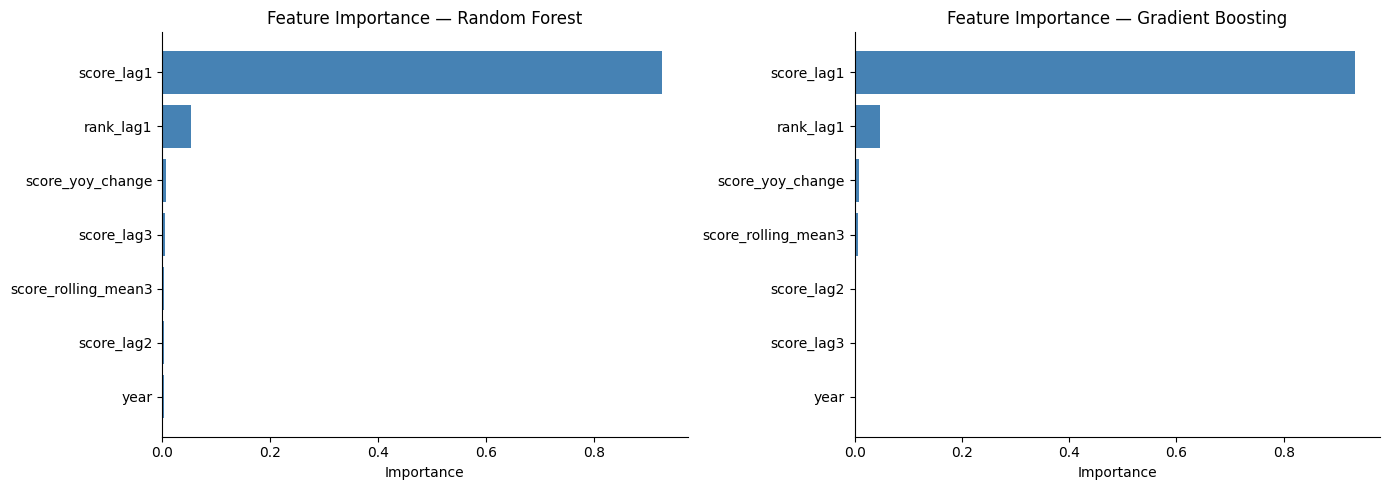

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    importances = results[name]['model'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    ax.barh([FEATURES_VALID[i] for i in sorted_idx][::-1],   # <-- ganti FEATURES → FEATURES_VALID
            importances[sorted_idx][::-1], color='steelblue')
    ax.set_title(f'Feature Importance — {name}', fontsize=12)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

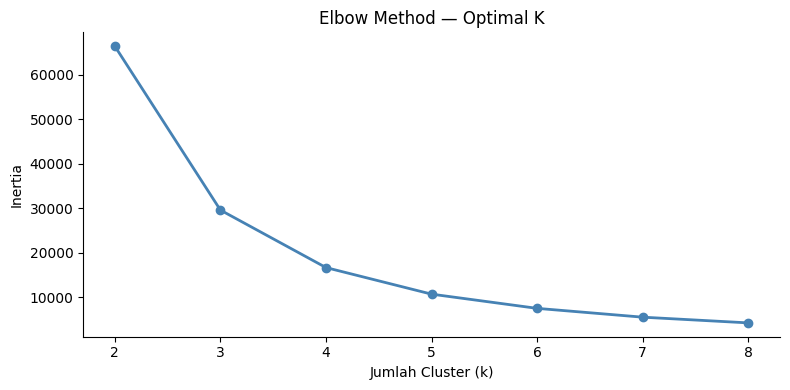

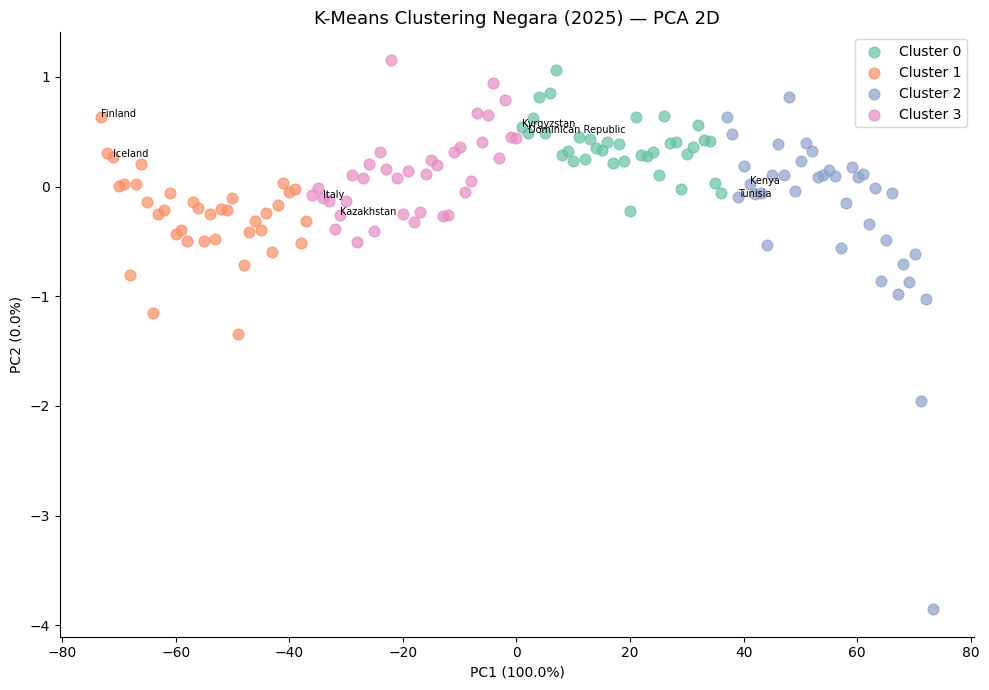

         score_lag1  score_lag2  score_lag3  score_rolling_mean3  \
cluster                                                            
0             5.309       5.265       5.201                5.259   
1             6.888       6.846       6.805                6.846   
2             3.978       3.946       4.047                3.990   
3             6.131       6.089       6.023                6.081   

         score_yoy_change  rank_lag1    year  happiness_score  
cluster                                                        
0                   0.044       92.5  2025.0            5.353  
1                   0.042       19.0  2025.0            6.919  
2                   0.032      129.0  2025.0            4.098  
3                   0.042       56.0  2025.0            6.221  


In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Ambil dari df_sorted (yang sudah punya kolom lag), bukan df
df_cluster = df_sorted[df_sorted['year'] == df_sorted['year'].max()]\
             .dropna(subset=FEATURES_VALID).copy().reset_index(drop=True)

X_c = df_cluster[FEATURES_VALID].values

# Elbow Method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_c)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K')
plt.xlabel('Jumlah Cluster (k)'); plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

# Fit KMeans
K_OPTIMAL = 4
km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cluster['cluster'] = km.fit_predict(X_c)

# PCA 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(X_c)
df_cluster['pca1'] = coords[:, 0]
df_cluster['pca2'] = coords[:, 1]

plt.figure(figsize=(10, 7))
for cluster in range(K_OPTIMAL):
    mask = df_cluster['cluster'] == cluster
    plt.scatter(df_cluster.loc[mask, 'pca1'], df_cluster.loc[mask, 'pca2'],
                label=f'Cluster {cluster}', s=60, alpha=0.7)
    for _, row in df_cluster[mask].nlargest(2, 'happiness_score').iterrows():
        plt.annotate(row['country'], (row['pca1'], row['pca2']), fontsize=7)

plt.title(f'K-Means Clustering Negara ({df_sorted["year"].max()}) — PCA 2D', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(); plt.tight_layout(); plt.show()

# Profil tiap cluster — ganti FEATURES → FEATURES_VALID
print(df_cluster.groupby('cluster')[FEATURES_VALID + ['happiness_score']].mean().round(3))

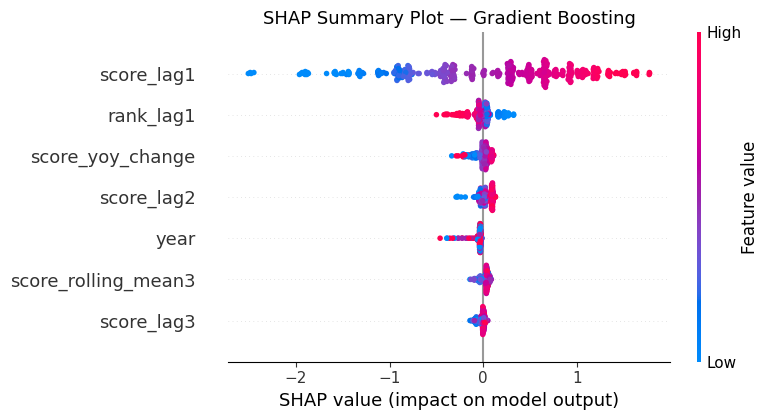

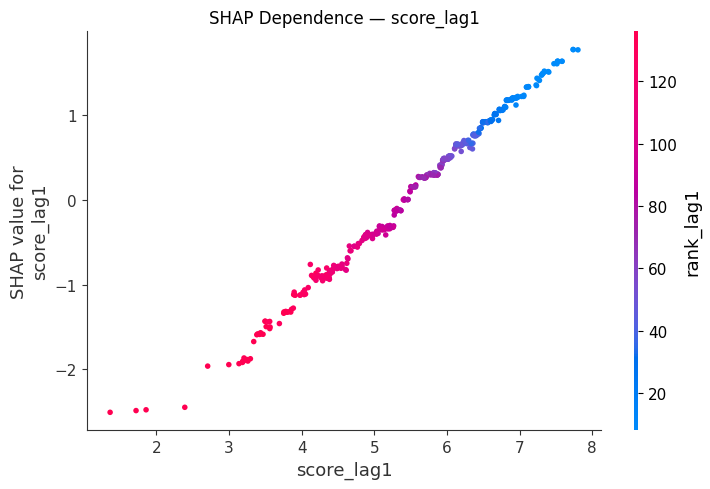

In [28]:
# Install jika belum: pip install shap
import shap

best_model = results['Gradient Boosting']['model']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES_VALID, show=False)
plt.title('SHAP Summary Plot — Gradient Boosting', fontsize=13)
plt.tight_layout(); plt.show()

# Dependence plot faktor terpenting
top_feature = FEATURES_VALID[np.abs(shap_values).mean(0).argmax()]
shap.dependence_plot(top_feature, shap_values, X_test, feature_names=FEATURES_VALID, show=False)
plt.title(f'SHAP Dependence — {top_feature}')
plt.tight_layout(); plt.show()

INFO:prophet:n_changepoints greater than number of observations. Using 10.


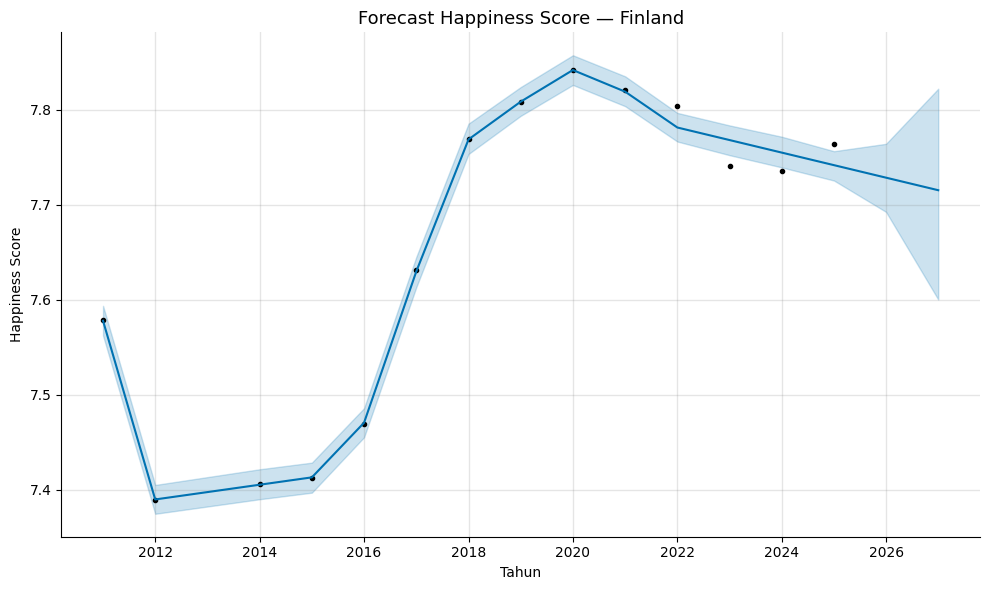

           ds      yhat  yhat_lower  yhat_upper
13 2025-01-01  7.741876    7.725667    7.756585
14 2025-12-31  7.728715    7.692680    7.764357
15 2026-12-31  7.715517    7.600498    7.822332


In [29]:
# Install jika belum: pip install prophet
from prophet import Prophet

# Pilih negara yang ingin di-forecast
COUNTRY = 'Finland'

ts = df[df['country'] == COUNTRY][['year', 'happiness_score']].dropna()
ts = ts.rename(columns={'year': 'ds', 'happiness_score': 'y'})
ts['ds'] = pd.to_datetime(ts['ds'], format='%Y')

m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
            changepoint_prior_scale=0.3)
m.fit(ts)

future = m.make_future_dataframe(periods=2, freq='YE')
forecast = m.predict(future)

fig = m.plot(forecast)
plt.title(f'Forecast Happiness Score — {COUNTRY}', fontsize=13)
plt.xlabel('Tahun'); plt.ylabel('Happiness Score')
plt.tight_layout(); plt.show()

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

In [30]:
print("=" * 60)
print("RINGKASAN INSIGHT — WORLD HAPPINESS REPORT 2011–2025")
print("=" * 60)

# 1. Negara terbahagia
top1 = df[df['year'] == df['year'].max()].nlargest(1, 'happiness_score').iloc[0]
print(f"\n1. Negara paling bahagia {df['year'].max()}: {top1['country']} ({top1['happiness_score']:.2f})")

# 2. Tren global
trend = df.groupby('year')['happiness_score'].mean()
delta = trend.iloc[-1] - trend.iloc[0]
print(f"2. Perubahan rata-rata global: {'+' if delta>0 else ''}{delta:.3f} dari {trend.index[0]} ke {trend.index[-1]}")

# 3. Korelasi terkuat
corr_with_score = df[num_cols].corr()['happiness_score'].drop('happiness_score').abs().sort_values(ascending=False)
print(f"3. Faktor paling berkorelasi dengan kebahagiaan:")
for col, val in corr_with_score.head(3).items():
    print(f"   - {col}: r = {val:.3f}")

# 4. Best model
best_name = max(results, key=lambda k: results[k]['R²'])
print(f"\n4. Model terbaik: {best_name} (R² = {results[best_name]['R²']:.4f}, RMSE = {results[best_name]['RMSE']:.4f})")

# 5. Cluster summary
print(f"\n5. Negara terbagi menjadi {K_OPTIMAL} cluster berdasarkan profil 6 faktor WHR")
print("=" * 60)

RINGKASAN INSIGHT — WORLD HAPPINESS REPORT 2011–2025

1. Negara paling bahagia 2025: Finland (7.76)
2. Perubahan rata-rata global: +0.258 dari 2011 ke 2025
3. Faktor paling berkorelasi dengan kebahagiaan:
   - explained_social_support: r = 0.701
   - explained_log_gdp_per_capita: r = 0.681
   - explained_healthy_life_expectancy: r = 0.659

4. Model terbaik: Ridge Regression (R² = 0.9754, RMSE = 0.1802)

5. Negara terbagi menjadi 4 cluster berdasarkan profil 6 faktor WHR
